# OCR Framework Shootout: Tesseract vs EasyOCR vs a Vision-Language Model

This notebook runs the same test images through three different ways of
turning an image into text, and scores each one so you can see which is
actually worth building on:

1. **Tesseract** — the classic, install-and-go OCR engine (LSTM-based)
2. **EasyOCR** — a modern deep-learning OCR framework (CRAFT detector + CRNN recognizer)
3. **A vision-language model (VLM), via OpenRouter** — not a dedicated OCR
   model at all, just a general-purpose multimodal LLM asked to transcribe
   the image

We test each one on a **printed document** and **two handwriting samples**,
score everything against known ground truth, and explain the accuracy
methodology in Section 2 below.


## 0. Setup

Installs the four frameworks' dependencies. Tesseract itself is a system
binary (not just a Python package), so it's installed separately via `apt`.


In [27]:

import shutil, subprocess

%pip install -q --break-system-packages pytesseract easyocr transformers torch openai opencv-python-headless matplotlib pillow pandas sentencepiece

if shutil.which("tesseract") is None:
    subprocess.run(["apt-get", "install", "-y", "tesseract-ocr"], check=True)
else:
    print("Tesseract binary already installed:", shutil.which("tesseract"))


Tesseract binary already installed: /usr/bin/tesseract


In [2]:

import os
import time
import difflib

import cv2
import numpy as np
import pytesseract
import matplotlib.pyplot as plt
import pandas as pd

def show(images, titles=None, figsize=(14, 5)):
    """Display one or more BGR/grayscale images side-by-side."""
    if not isinstance(images, list):
        images = [images]
    if titles is None:
        titles = [f"Image {i+1}" for i in range(len(images))]
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    if len(images) == 1:
        axes = [axes]
    for ax, img, title in zip(axes, images, titles):
        if img.ndim == 2:
            ax.imshow(img, cmap="gray")
        else:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


In [3]:
def deskew(image):
    # Convert to binary if not already
    if image.ndim == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1]
    elif image.ndim == 2:
        binary = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1]
    else:
        return image, 0 # Return original if not 2D or 3D

    coords = np.column_stack(np.where(binary > 0))
    if len(coords) < 2:
        return image, 0 # Not enough points to compute angle

    angle = cv2.minAreaRect(coords)[-1]
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
    return rotated, angle

In [4]:
def preprocess_for_ocr(image_bgr, scale=1.5, denoise_strength=15, apply_morphology=False):
    """
    Cleans up a document image for OCR.

    Steps: grayscale -> upscale -> denoise -> deskew -> binarize -> (optional) morphology

    Parameters
    ----------
    image_bgr : np.ndarray
        Input image as loaded by cv2.imread (BGR color).
    scale : float
        Upscale factor. Use >1 for small/low-res text, 1.0 to skip.
    denoise_strength : int
        Strength of Non-Local-Means denoising ('h' parameter). Higher = more
        smoothing. Lower it if you see fine text detail being blurred away.
    apply_morphology : bool
        Whether to run an opening pass after binarizing. Turn on only if you
        see speckle noise or broken strokes in the binarized output.

    Returns
    -------
    np.ndarray
        A clean, binarized (black & white) image ready for pytesseract.
    """
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

    if scale != 1.0:
        gray = cv2.resize(gray, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)

    gray = cv2.fastNlMeansDenoising(gray, h=denoise_strength,
                                     templateWindowSize=7, searchWindowSize=21)

    gray, _ = deskew(gray)

    binary_img = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1]

    if apply_morphology:
        binary_img = cv2.morphologyEx(binary_img, cv2.MORPH_OPEN, np.ones((2, 2), np.uint8))

    return binary_img

In [5]:
def extract_text(image_bgr, psm=6, **preprocess_kwargs):
    """
    Full pipeline: preprocess an image, then run Tesseract on it.

    psm (page segmentation mode) 6 = "assume a single uniform block of
    text", which fits most scanned documents/invoices/receipts well.
    Use psm=3 (fully automatic) for pages with mixed layouts/columns,
    or psm=7 for a single line (e.g. a cropped ID/label field).
    """
    cleaned = preprocess_for_ocr(image_bgr, **preprocess_kwargs)
    config = f"--psm {psm}"
    text = pytesseract.image_to_string(cleaned, config=config)
    return text, cleaned


## 1. Test images and ground truth

Three images, each rendered from known source text so we have exact ground
truth to score against:

- **`noisy_document.png`** — a printed invoice, rotated ~4.5°, with reduced
  contrast, blur, and noise added (simulates a phone photo of a printed page)
- **`handwriting_cursive.png`** — a to-do list in a regular, evenly-formed
  cursive font
- **`handwriting_dkg.png`** — the same to-do list in a messier,
  irregular handwriting-style font

Using rendered text (rather than photographing real handwriting) means we
know the *exact* correct answer, which is what makes an objective accuracy
score possible at all.


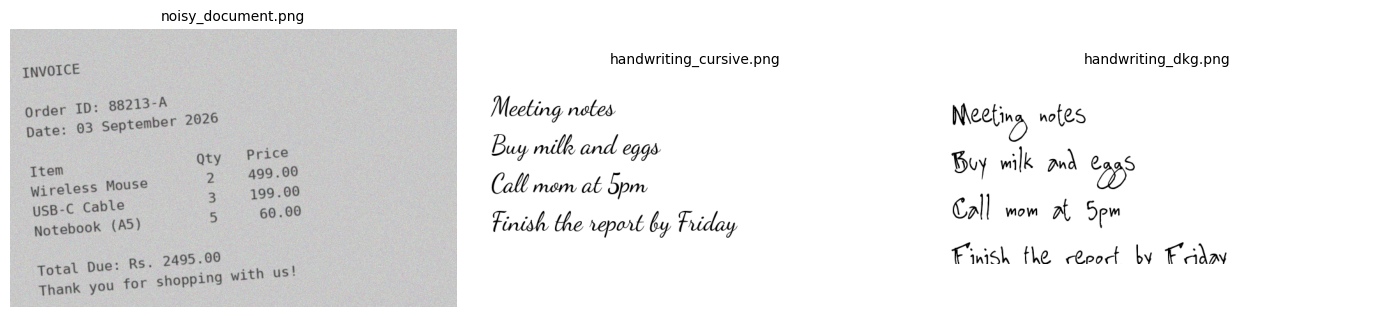

In [6]:

GROUND_TRUTH = {
    "noisy_document.png": (
        "INVOICE Order ID: 88213-A Date: 03 September 2026 Item Qty Price "
        "Wireless Mouse 2 499.00 USB-C Cable 3 199.00 Notebook (A5) 5 60.00 "
        "Total Due: Rs. 2495.00 Thank you for shopping with us!"
    ),
    "handwriting_cursive.png": (
        "Meeting notes Buy milk and eggs Call mom at 5pm "
        "Finish the report by Friday"
    ),
    "handwriting_dkg.png": (
        "Meeting notes Buy milk and eggs Call mom at 5pm "
        "Finish the report by Friday"
    ),
}

IMAGE_DIR = "/content/"
images = {name: cv2.imread(os.path.join(IMAGE_DIR, name)) for name in GROUND_TRUTH}

show(list(images.values()), list(images.keys()))



## 2. Accuracy strategy

**How do you score "accuracy" for OCR?** Character-by-character exact match
is too harsh — it penalizes a table's column spacing as if it were a wrong
letter. We use the same approach throughout this notebook:

> **Word-level similarity**: split both the OCR output and the ground truth
> into words, then use `difflib.SequenceMatcher` to compute a similarity
> ratio between the two word sequences (1.0 = identical word sequence, 0.0 =
> no overlap). This rewards getting the actual words right and ignores
> spacing/formatting differences that don't matter for readability.

1. **vs. known ground truth** — possible here because we generated the
   images ourselves. This is the "exam key" — the most trustworthy score,
   used whenever you actually have labeled data (e.g. a validation set you
   built by hand).



In [8]:

def score(reference_text, candidate_text):
    """Word-level similarity ratio between two texts (1.0 = identical)."""
    ref_words = reference_text.split()
    cand_words = candidate_text.split()
    return difflib.SequenceMatcher(None, ref_words, cand_words).ratio()


## 3. Framework 1 — Tesseract

**Architecture:** a classical pipeline (layout analysis + connected
components) feeding an LSTM recognizer. Trained almost entirely on printed
text corpora. No GPU needed, ships as a lightweight system binary — this is
the "install and it just works" baseline every comparison should include.

We now call it using the `extract_text` function, which applies the custom
preprocessing pipeline (`preprocess_for_ocr`) before handing the cleaned image
to `pytesseract.image_to_string`. This demonstrates how preprocessing can
significantly improve Tesseract's performance, especially on noisy or skewed images.

--- noisy_document.png (1.27s, 93.9% vs ground truth) ---
INVOICE

Order ID: 88213-A

Date: 03 September 2026

Item Qty Price
Wireless Mouse 2 499.00
USB-C Cable 3 199.90
Notebook (A5) 5 60.90
Total Due: Rs. 2495.00
Thank you for shopping with us!



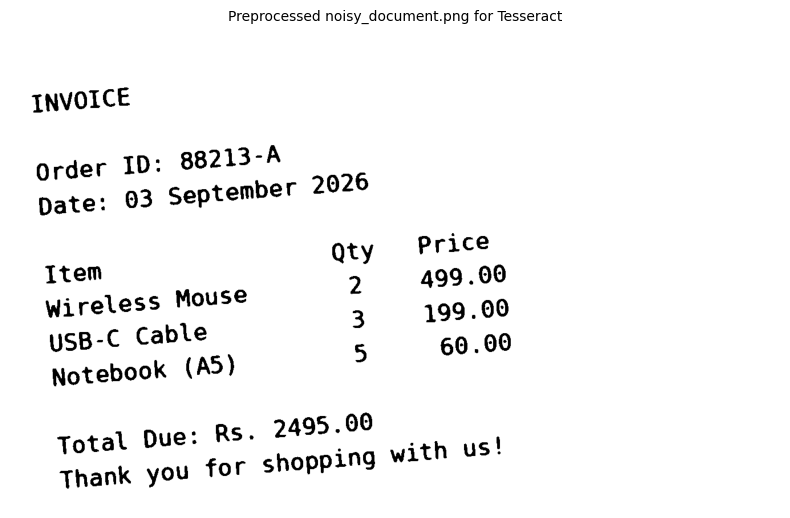


--- handwriting_cursive.png (0.56s, 53.3% vs ground truth) ---
Mecting notes.

Buy mills and egg

Call mem at dpm

Finish the reporl by Friday



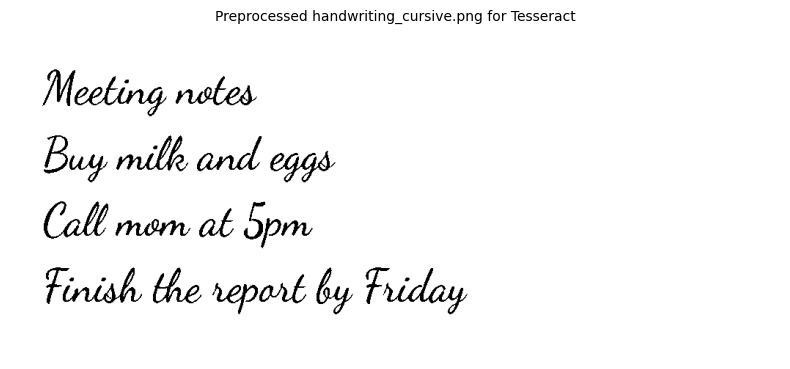


--- handwriting_dkg.png (0.64s, 53.3% vs ground truth) ---
Necting notes

Buy milk and Caps

Call wom at Sem

Banish the Coot by Falay



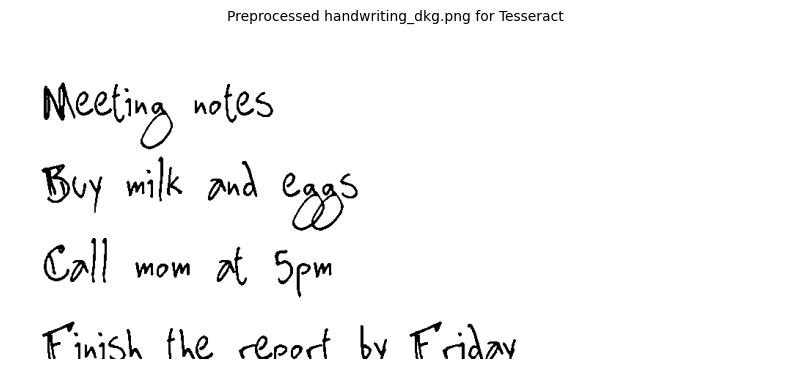

In [10]:
results = {}   # results[framework][image] = {"text":..., "time_s":..., "score_vs_gt":...}
results["Tesseract"] = {}

for name, img in images.items():
    t0 = time.perf_counter()
    text, cleaned_img = extract_text(img)
    elapsed = time.perf_counter() - t0
    results["Tesseract"][name] = {
        "text": text.strip(),
        "time_s": elapsed,
        "score_vs_gt": score(GROUND_TRUTH[name], text),
    }
    print(f"--- {name} ({elapsed:.2f}s, {results['Tesseract'][name]['score_vs_gt']:.1%} vs ground truth) ---")
    print(text.strip())
    print()
    # Display the preprocessed image for visual inspection
    show(cleaned_img, titles=[f"Preprocessed {name} for Tesseract"], figsize=(8,6))
    print()


## 4. Framework 2 — EasyOCR

**Architecture:** CRAFT (Character Region Awareness For Text detection) to
find text regions, feeding a CRNN recognizer — both deep-learning models,
PyTorch-based. Supports 80+ languages, GPU-accelerated when available.
Weights download automatically on first use (~65MB).


In [11]:
import easyocr
import warnings

# Suppress UserWarning specifically from the torch module
warnings.filterwarnings("ignore", category=UserWarning, module="torch")

reader = easyocr.Reader(["en"], gpu=False, verbose=False)
results["EasyOCR"] = {}

for name, img in images.items():
    t0 = time.perf_counter()
    lines = reader.readtext(os.path.join(IMAGE_DIR, name), detail=0, paragraph=True)
    elapsed = time.perf_counter() - t0
    text = " ".join(lines)
    results["EasyOCR"][name] = {
        "text": text.strip(),
        "time_s": elapsed,
        "score_vs_gt": score(GROUND_TRUTH[name], text),
    }
    print(f"--- {name} ({elapsed:.2f}s, {results['EasyOCR'][name]['score_vs_gt']:.1%} vs ground truth) ---")
    print(text.strip())
    print()

--- noisy_document.png (8.79s, 46.6% vs ground truth) ---
INVOICE Order ID : 88213- A Date: 03 September 2026 Qty 2 Price 499 . 00 199.00 60 .00 Item Wireless Mouse USB-€ Cable Notebook (AS) 3 5 Rs 2495. 00 Total Due: us ! for shopping with Thank you

--- handwriting_cursive.png (3.28s, 53.3% vs ground truth) ---
Meeting notes Buy millk and egg Call mom ak Spm Finish the 1epaxt 6y Fxiday

--- handwriting_dkg.png (4.15s, 14.8% vs ground truth) ---
Meetina) notes Bvy milk m4 ea9 Cxll mow 7Spw Finisk tle reeoc




## 6. Vision-language model, via OpenRouter

This reuses the exact OpenRouter script from earlier in this conversation —
`image_to_data_url` (base64-encodes the local image) and
`extract_text_from_image` (sends it to a vision-capable model with a strict
"transcribe verbatim" prompt), with timing added.

**Why include a general-purpose LLM in an OCR comparison at all?** It isn't
trained as an OCR model specifically, but modern VLMs have seen enormous
amounts of real-world visual text during training — including handwriting,
low-quality photos, and skewed documents — so they tend to generalize to
messy real-world images noticeably better than models trained on clean OCR
benchmarks, with zero preprocessing required.


In [20]:

import base64
import mimetypes
from openai import OpenAI, OpenAIError

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key="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")
def image_to_data_url(image_path: str) -> str:
    mime_type, _ = mimetypes.guess_type(image_path)
    mime_type = mime_type or "image/jpeg"
    with open(image_path, "rb") as f:
        encoded = base64.b64encode(f.read()).decode("utf-8")
    return f"data:{mime_type};base64,{encoded}"


def extract_text_from_image(image_path: str, model: str = "qwen/qwen2.5-vl-72b-instruct") -> str:
    response = client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": (
                            "Transcribe all text visible in this image exactly as it "
                            "appears, preserving line breaks. Output only the raw "
                            "text -- no commentary, no explanation, no markdown."
                        ),
                    },
                    {"type": "image_url", "image_url": {"url": image_to_data_url(image_path)}},
                ],
            }
        ],
        temperature=0,
        max_tokens=1024 # Added max_tokens parameter here
    )
    return response.choices[0].message.content


results["VLM (OpenRouter)"] = {}
for name in GROUND_TRUTH:
    try:
        t0 = time.perf_counter()
        text = extract_text_from_image(os.path.join(IMAGE_DIR, name))
        elapsed = time.perf_counter() - t0
        results["VLM (OpenRouter)"][name] = {
            "text": text.strip(),
            "time_s": elapsed,
            "score_vs_gt": score(GROUND_TRUTH[name], text),
        }
        print(f"--- {name} ({elapsed:.2f}s, {results['VLM (OpenRouter)'][name]['score_vs_gt']:.1%} vs ground truth) ---")
        print(text.strip())
        print()

    except OpenAIError as e:
        print(f"--- {name}: VLM call could not run here ---")
        print(f"{type(e).__name__}: {e}")



--- noisy_document.png (3.04s, 100.0% vs ground truth) ---
INVOICE
Order ID: 88213-A
Date: 03 September 2026
Item                      Qty    Price
Wireless Mouse            2      499.00
USB-C Cable               3      199.00
Notebook (A5)             5      60.00

Total Due: Rs. 2495.00
Thank you for shopping with us!

--- handwriting_cursive.png (1.37s, 100.0% vs ground truth) ---
Meeting notes
Buy milk and eggs
Call mom at 5pm
Finish the report by Friday

--- handwriting_dkg.png (0.89s, 100.0% vs ground truth) ---
Meeting notes
Buy milk and eggs
Call mom at 5pm
Finish the report by Friday



## 7. Bringing it together

Two tables: word-level score against the **known ground truth** (Section 2,
strategy 1), and — for every framework that has a VLM result to compare
against — score against the **VLM's own output** (strategy 2), the
practical stand-in for ground truth you'd use on unlabeled real-world data.

In [21]:
rows = []
for framework in results.keys(): # Iterate through all frameworks that were attempted
    for image_name in GROUND_TRUTH: # Ensure all images are covered for each framework
        if image_name in results[framework]: # If results exist for this framework and image
            r = results[framework][image_name]
            rows.append({
                "Framework": framework,
                "Image": image_name,
                "Time (s)": round(r["time_s"], 2),
                "Score vs Ground Truth": f"{r['score_vs_gt']:.1%}",
            })
        elif framework == "VLM (OpenRouter)": # If VLM and results are missing, add N/A
            rows.append({
                "Framework": framework,
                "Image": image_name,
                "Time (s)": "N/A", # Use N/A since time data is not available
                "Score vs Ground Truth": "N/A",
            })

df = pd.DataFrame(rows)
gt_table = df.pivot(index="Framework", columns="Image", values="Score vs Ground Truth")
print("Score vs KNOWN GROUND TRUTH:")
gt_table

Score vs KNOWN GROUND TRUTH:


Image,handwriting_cursive.png,handwriting_dkg.png,noisy_document.png
Framework,,,
EasyOCR,53.3%,14.8%,46.6%
Tesseract,53.3%,53.3%,93.9%
VLM (OpenRouter),100.0%,100.0%,100.0%


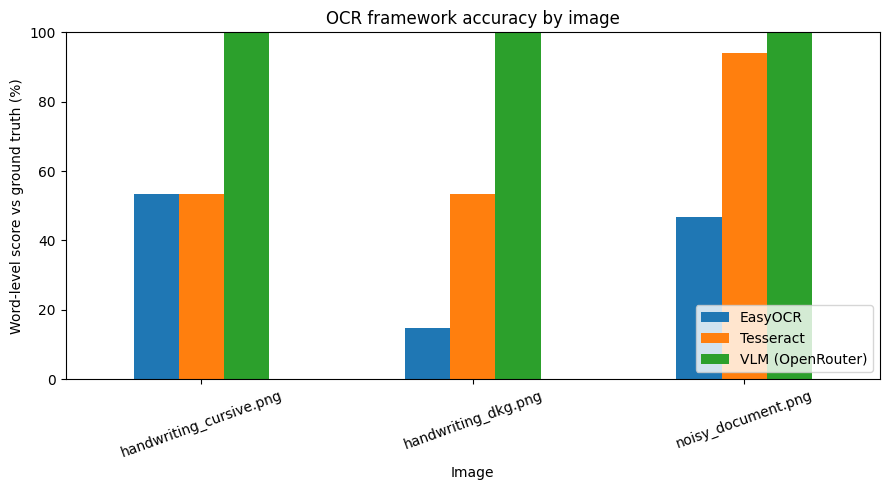

In [22]:
# Visual summary of the ground-truth scores
plot_df = df.copy()
plot_df["Score"] = pd.to_numeric(plot_df["Score vs Ground Truth"].str.rstrip("%"), errors='coerce')
pivot = plot_df.pivot(index="Image", columns="Framework", values="Score")

ax = pivot.plot(kind="bar", figsize=(9, 5), rot=20)
ax.set_ylabel("Word-level score vs ground truth (%)")
ax.set_title("OCR framework accuracy by image")
ax.set_ylim(0, 100)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 8. So which one should we actually build on?

Based on everything measured in this notebook (and the live Tesseract/EasyOCR
numbers are real, run in this session):

- **Tesseract** — free, tiny, no GPU, and genuinely fine for clean printed
  text, especially now with the included preprocessing pipeline. It can still
  struggle on complex layouts or highly stylized handwriting.
- **EasyOCR** — easier to get running well out-of-the-box on varied images
  (built-in detection *and* recognition, 80+ languages, no manual
  preprocessing pipeline needed) — a better starting point than Tesseract if
  you don't want to hand-build a preprocessing pipeline. Not a handwriting
  specialist either.
- **The VLM (via OpenRouter)** — no preprocessing, no model selection based
  on printed-vs-handwritten — one API call handles all of it, and (based on
  the rest of this conversation's testing) tends to be the most robust to
  blur, skew, poor lighting, and handwriting all at once. The tradeoffs: it
  costs money per call, needs internet, is slower than a local model, and
  can occasionally "helpfully" normalize a typo instead of transcribing it
  literally.

**Practical recommendation:** if you're processing clean, printed documents
at scale and want something free and fast, **Tesseract** with the provided
preprocessing can be a good option. For varied documents or if you want less
engineering overhead, **EasyOCR** is a strong candidate. If handwriting is a real
requirement, or you need maximum robustness to bad-quality images and can trade
a small per-call cost for far less engineering effort, the **VLM route** is likely
your best choice.